In [9]:
import os
import random
import shutil
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [10]:
import shutil

from PIL import Image

def split_dataset(source_dir, output_dir, train_percentage=80):

    classes = ["Cat", "Dog"]

    for class_name in classes:

        source_class = os.path.join(source_dir, class_name)

        images = []

        for file in os.listdir(source_class):

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            ):
                images.append(file)

        random.shuffle(images)

        split_index = int(len(images) * train_percentage / 100)

        train_images = images[:split_index]

        test_images = images[split_index:]

        train_folder = os.path.join(output_dir, "train", class_name)

        test_folder = os.path.join(output_dir, "test", class_name)

        os.makedirs(train_folder, exist_ok=True)

        os.makedirs(test_folder, exist_ok=True)

        for image in train_images:
            shutil.copy2(
                os.path.join(source_class, image),
                os.path.join(train_folder, image)
            )

        for image in test_images:
            shutil.copy2(
                os.path.join(source_class, image),
                os.path.join(test_folder, image)
            )

    print("Dataset split complete")

In [11]:
#split_dataset(
   # source_dir="dataset",
  #  output_dir="cats_dogs_split",
 #   train_percentage=80
#)

In [4]:
for root, dirs, files in os.walk("cats_dogs_split"):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img = img.convert("RGB")
            img = img.resize((128, 128))
            img.save(path)

        except:
            os.remove(path)
            print("deleted", path)

print("cleaning DONE") 

C:\Users\hites\anaconda3\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


cleaning DONE


In [13]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "cats_dogs_split/train",
    image_size=(128,128),
    batch_size=32
)

Found 19966 files belonging to 2 classes.


In [14]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "cats_dogs_split/test",
    image_size=(128,128),
    batch_size=32
)


Found 4992 files belonging to 2 classes.


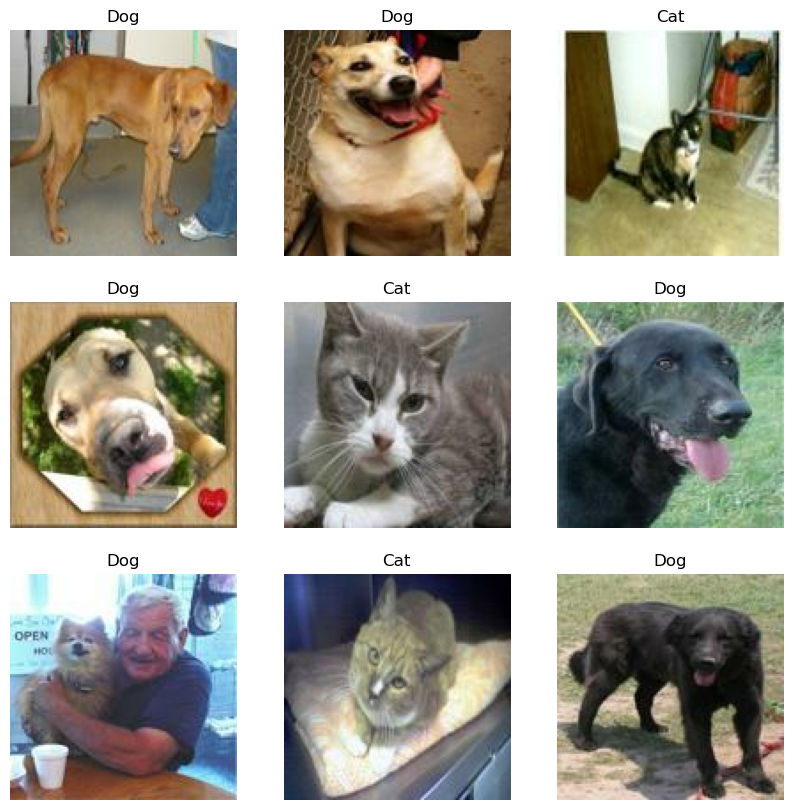

In [15]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_dataset.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 122s 193ms/step - accuracy: 0.6614 - loss: 0.6008 - val_accuracy: 0.7540 - val_loss: 0.5090
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 104s 166ms/step - accuracy: 0.7708 - loss: 0.4806 - val_accuracy: 0.7943 - val_loss: 0.4357
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 98s 156ms/step - accuracy: 0.8157 - loss: 0.4036 - val_accuracy: 0.8083 - val_loss: 0.4026
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 105s 168ms/step - accuracy: 0.8497 - loss: 0.3406 - val_accuracy: 0.8207 - val_loss: 0.3955
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 105s 168ms/step - accuracy: 0.8816 - loss: 0.2744 - val_accuracy: 0.8107 - val_loss: 0.4451
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 112s 180ms/step - accuracy: 0.9204 - loss: 0.1943 - val_accuracy: 0.8013 - val_loss: 0.5619
Epoch 7/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 98s 157ms/step - accuracy: 0.9518 - loss: 0.1265 - val_accuracy: 0.8185 - val_loss: 0.6405
Epoch 8/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.9678 - lo

In [21]:
loss , accuracy = model.evaluate(test_dataset)

156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8121 - loss: 0.9160


In [22]:
print(loss)

0.9159725904464722


In [23]:
print(accuracy)

0.8120993375778198


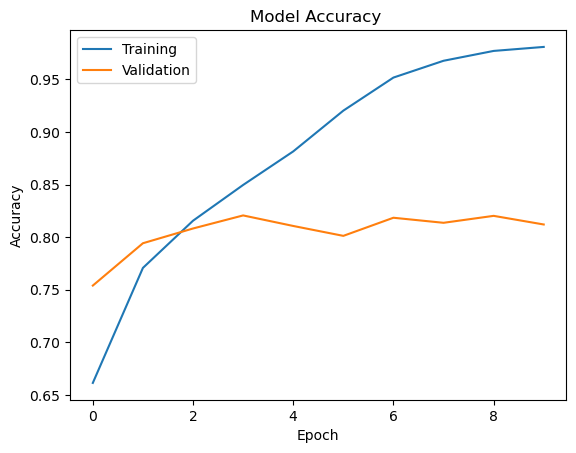

In [26]:
plt.plot(history.history["accuracy"])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy ")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])
plt.show()

In [32]:
img = tf.keras.preprocessing.image.load_img(

    r"C:\Users\hites\linux world\archive\DATASET\cats_dogs_split\test\Cat\12.jpg",
    target_size=(128,128)
)

In [33]:
img_array = tf.keras.preprocessing.image.img_to_array(img)

In [34]:
img_array = np.expand_dims(img_array, axis=0)

In [35]:
predtion = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [36]:
if predtion[0][0] > 0.5 :
    print("DOG")
else:
    print("Cat")

Cat


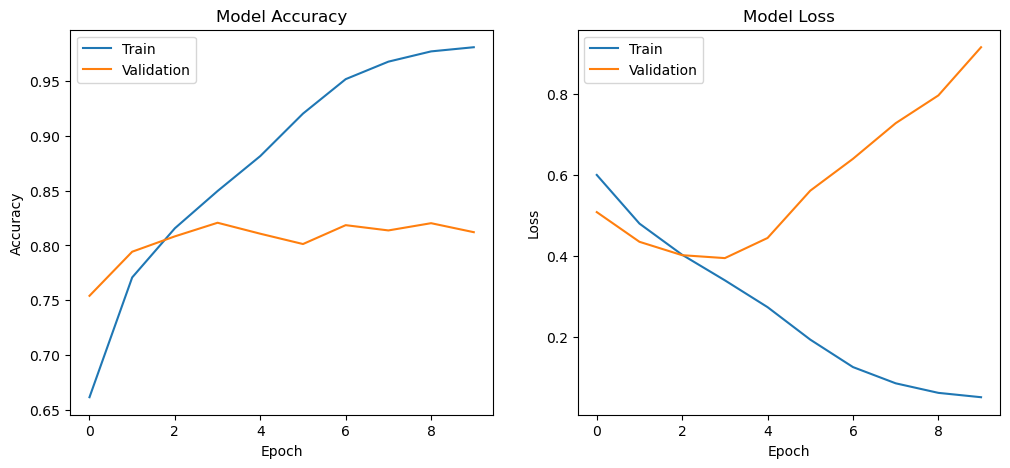

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [31]:
loss, accuracy = model.evaluate(test_dataset)

print("Loss:", loss)
print("Accuracy:", accuracy)

img = tf.keras.preprocessing.image.load_img(
    r"C:\Users\hites\linux world\archive\DATASET\cats_dogs_split\test\Cat\12.jpg",
    target_size=(128,128)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8121 - loss: 0.9160
Loss: 0.9159727096557617
Accuracy: 0.8120993375778198
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Cat
